# volkit — Library Guide

A complete walkthrough of every module in volkit — from data ingestion to the variance risk premium signal.

| Module | What it does |
|--------|--------------|
| market_data | Fetch options chains and price history from multiple providers |
| black_scholes | Price options and compute Greeks from scratch |
| iv_surface | Build implied volatility surfaces using Newton-Raphson |
| vol_spread | Compute the variance risk premium signal |

---

In [22]:
from volkit import market_data
from volkit.black_scholes import bs_price, greeks
from volkit.iv_surface import plot_surface, build_iv_surface, implied_volatility as iv_solver
from volkit.vol_spread import analyze_vol_spread, realized_vol, atm_implied_vol, compute_vol_spread
from volkit.market_data.providers.yahoo import YahooProvider
from volkit.market_data.providers.massive_provider import MassiveProvider
from volkit.market_data.providers.marketdata_provider import MarketDataProvider

from datetime import datetime
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import yfinance as yf
import os

load_dotenv()

True

---
## 1. market_data

The data layer is built around a **provider pattern** — an abstract base class defines a contract of three methods, and each provider implements it for a specific data source. The rest of the library never depends on a specific provider.

| Provider | Price History | Options Chain | Greeks | API Key |
|----------|:---:|:---:|:---:|:---:|
| Yahoo Finance | ✓ | ✓ | ✗ | Not required |
| Massive | ✓ | Paid plan only | ✗ | Required |
| MarketData.app | ✓ | ✓ | ✓ | Required (free tier) |

> **Note:** Yahoo Finance does not provide liquid puts far below spot (bid = ask = 0 during market close; mid falls back to `lastPrice`). 
When market is closed -> use with a dataset

### 1.1 Price History

In [23]:
# Yahoo Finance
provider_yahoo = YahooProvider()

# using period
df_period = provider_yahoo.get_price_history("SPY", period="1y")
print(f"{len(df_period)} bars — {df_period.index[0].date()} to {df_period.index[-1].date()}")

# using explicit date range
df_range = provider_yahoo.get_price_history("SPY", start="2023-01-01", end="2024-01-01")
print(f"{len(df_range)} bars — {df_range.index[0].date()} to {df_range.index[-1].date()}")

df_range.head()

252 bars — 2025-04-22 to 2026-04-22
250 bars — 2023-01-03 to 2023-12-29


,open,high,low,close,volume
Date,,,,,
2023-01-03,368.475238,370.450049,362.205677,365.072052,74850700
2023-01-04,367.334471,369.922831,364.285980,367.890503,85934100
2023-01-05,365.934851,366.049884,363.097263,363.691620,76970500
2023-01-06,366.788058,373.153491,363.720404,372.031860,104189600
2023-01-09,374.227106,377.419418,371.638776,371.820892,73978100


In [3]:
# Massive — requires API key, free tier limited to recent data
# Note: historical data beyond ~2 years requires a paid plan
massive_key = os.getenv("MASSIVE_API_KEY")

provider_massive = MassiveProvider(api_key=massive_key)

df_massive = provider_massive.get_price_history("SPY", period="1y")

print(f"{len(df_massive)} bars — {df_massive.index[0].date()} to {df_massive.index[-1].date()}")

df_massive.tail()

251 bars — 2025-04-22 to 2026-04-21


,open,high,low,close,volume
date,,,,,
2026-04-15,695.26,700.280,694.20,699.94,5.824038e+07
2026-04-16,701.06,702.780,698.53,701.66,4.997236e+07
2026-04-17,706.14,712.390,705.76,710.14,7.066193e+07
2026-04-20,708.78,709.910,706.14,708.72,4.353164e+07
2026-04-21,710.28,711.275,702.64,704.08,5.890047e+07


In [ ]:
# provider comparison — Yahoo vs Massive for same ticker and period
# prices differ slightly due to adjusted vs unadjusted data

df_yahoo  = provider_yahoo.get_price_history("SPY", start="2025-01-01", end="2025-06-01")
df_massive = provider_massive.get_price_history("SPY", start="2025-01-01", end="2025-06-01")

common = df_yahoo.index.intersection(df_massive.index)
first_date = common[0].date()
print(f"Common dates: {len(common)}")
print(f"Yahoo   close {first_date}: {df_yahoo.loc[common[0], 'close']:.2f}")
print(f"Massive close {first_date}: {df_massive.loc[common[0], 'close']:.2f}")

Common dates: 102
Yahoo  close 2025-01-02: 576.28
Massive close 2025-01-02: 584.64


### 1.2 Options Chain

In [25]:
# Yahoo — fetch all expiries
options_all = provider_yahoo.get_options_chain("SPY")
print(f"All expiries: {len(options_all)} rows, {options_all['expiry'].nunique()} expiries")
print("Note: Yahoo does not provide Greeks — use MarketData.app for delta, gamma, vega, theta")
options_all.head()

All expiries: 8400 rows, 32 expiries
Note: Yahoo does not provide Greeks — use MarketData.app for delta, gamma, vega, theta


,strike,bid,ask,last,open_interest,volume,implied_volatility,option_type,expiry,mid
0,600.0,108.26,111.05,79.73,6.0,NaN,1.747072,call,2026-04-22,109.655
1,639.0,70.60,70.69,65.10,7.0,8.0,0.000010,call,2026-04-22,70.645
2,641.0,68.64,68.72,67.56,30.0,1.0,0.000010,call,2026-04-22,68.680
3,646.0,63.63,63.71,63.05,5.0,1.0,0.000010,call,2026-04-22,63.670
4,650.0,59.62,59.70,59.52,47.0,3.0,0.000010,call,2026-04-22,59.660


In [26]:
# filter by expiry range
options_filtered = provider_yahoo.get_options_chain(
    "SPY",
    expiry_from="2026-05-01",
    expiry_to="2026-09-30"
)
print(f"Filtered: {len(options_filtered)} rows")
print(f"Expiries: {sorted(options_filtered['expiry'].unique())}")

options_filtered

Filtered: 3851 rows
Expiries: ['2026-05-01', '2026-05-04', '2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-18', '2026-06-30', '2026-07-17', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30']


,strike,bid,ask,last,open_interest,volume,implied_volatility,option_type,expiry,mid
1724,400.0,308.73,311.17,310.61,29.0,29.0,1.614748,call,2026-05-01,309.950
1725,500.0,208.79,211.38,200.79,17.0,3.0,1.083012,call,2026-05-01,210.085
1726,510.0,198.81,201.32,200.98,6.0,6.0,1.019780,call,2026-05-01,200.065
1727,520.0,188.47,191.75,162.65,5.0,3.0,1.031499,call,2026-05-01,190.110
1728,530.0,178.84,181.66,110.30,26.0,26.0,0.966065,call,2026-05-01,180.250
...,...,...,...,...,...,...,...,...,...,...
5570,725.0,34.02,34.12,34.41,505.0,15.0,0.137300,put,2026-09-30,34.070
5571,730.0,36.26,36.36,37.95,717.0,133.0,0.132592,put,2026-09-30,36.310
5572,740.0,41.31,41.60,45.57,365.0,2.0,0.124322,put,2026-09-30,41.455
5573,750.0,47.14,47.49,47.82,13.0,2.0,0.115121,put,2026-09-30,47.315


In [ ]:
# MarketData.app — includes Greeks (delta, gamma, theta, vega)
# Note: free tier has daily credit limits — fetching expiration=all costs many credits on large tickers
md_key = os.getenv("MARKETDATA_API_KEY")

provider_md = MarketDataProvider(api_key=md_key)
options_md  = provider_md.get_options_chain("SPY", expiry="2026-05-15")

options_md

### 1.3 Market Snapshot

get_market_snapshot() returns everything at once: spot price, price history, and options chain in a single call.

In [60]:
# fetch snapshot for three tickers
tickers = ["SPY", "AAPL", "NVDA", "TSLA", "GOOG", "QQQ"]
snapshots = {}

for ticker in tickers:
    print(f"{ticker}:")
    snapshots[ticker] = market_data.get_market_snapshot(
        ticker,
        expiry_from="2026-05-01",
        expiry_to="2026-12-31"
    )
    print()

snapshots["AAPL"]["options"]

SPY:
  Spot price    : $710.06
  Price bars    : 252
  Options rows  : 4397
  Expiries      : 16

AAPL:
  Spot price    : $272.68
  Price bars    : 252
  Options rows  : 1188
  Expiries      : 13

NVDA:
  Spot price    : $201.36
  Price bars    : 252
  Options rows  : 2442
  Expiries      : 13

TSLA:
  Spot price    : $390.00
  Price bars    : 252
  Options rows  : 2463
  Expiries      : 13

GOOG:
  Spot price    : $335.46
  Price bars    : 252
  Options rows  : 1156
  Expiries      : 11

QQQ:
  Spot price    : $652.82
  Price bars    : 252
  Options rows  : 3860
  Expiries      : 15



,strike,bid,ask,last,open_interest,volume,implied_volatility,option_type,expiry,mid
232,190.0,80.00,83.20,75.50,12.0,11.0,1.144536,call,2026-05-01,81.600
233,200.0,70.55,73.10,71.00,30.0,5.0,0.962891,call,2026-05-01,71.825
234,205.0,65.55,68.25,60.00,7.0,5.0,0.951661,call,2026-05-01,66.900
235,210.0,60.55,62.65,61.63,72.0,5.0,0.000010,call,2026-05-01,61.600
236,215.0,55.60,58.30,51.79,25.0,3.0,0.830568,call,2026-05-01,56.950
...,...,...,...,...,...,...,...,...,...,...
1415,310.0,42.75,45.25,45.50,68.0,6.0,0.230568,put,2026-12-18,44.000
1416,315.0,46.55,49.05,56.70,10.0,1.0,0.228157,put,2026-12-18,47.800
1417,320.0,50.45,52.95,62.00,74.0,1.0,0.225166,put,2026-12-18,51.700
1418,330.0,58.60,61.35,60.80,52.0,1.0,0.222908,put,2026-12-18,59.975


In [9]:
snapshots["NVDA"]["expiries"]

['2026-05-15',
 '2026-06-18',
 '2026-08-21',
 '2026-09-18',
 '2026-10-16',
 '2026-11-20',
 '2026-12-18']

---
## 2. black_scholes

Implements the Black-Scholes formula from scratch — no external pricing libraries. Given five inputs — spot (S), strike (K), time to expiry (T), risk-free rate (r), volatility (sigma) — it returns the theoretical option price and all five Greeks.


d1 = [ln(S/K) + (r + σ²/2)·T] / (σ·√T)

d2 = d1 − σ·√T

Call = S·N(d1) − K·e^(−rT)·N(d2)

Put  = K·e^(−rT)·N(−d2) − S·N(−d1)


### 2.1 Option Pricing

In [46]:
from volkit.utils import get_risk_free_rate

# price call and put for SPY
S = snapshots["SPY"]["spot"]
K = round(S / 5) * 5       # nearest $5 strike to ATM
T = 30 / 365               # 30 days to expiry
r = get_risk_free_rate()   # risk-free rate
sigma = 0.18               # assumed volatility

call_price = bs_price(S=S, K=K, T=T, r=r, sigma=sigma, option_type="call")
put_price  = bs_price(S=S, K=K, T=T, r=r, sigma=sigma, option_type="put")

print(f"Spot:       ${S:.2f}")
print(f"Strike:     ${K:.2f}")
print(f"Risk-free:  {r*100:.2f}%")
print(f"Call price: ${call_price:.2f}")
print(f"Put price:  ${put_price:.2f}")

Spot:       $709.59
Strike:     $710.00
Risk-free:  3.60%
Call price: $15.45
Put price:  $13.76


In [29]:
# price to chagnges in volatility
print(f"{'Sigma':>8} {'Call Price':>12} {'Put Price':>12}")

for vol in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    c = bs_price(S=S, K=K, T=T, r=r, sigma=vol, option_type="call")
    p = bs_price(S=S, K=K, T=T, r=r, sigma=vol, option_type="put")
    print(f"{vol*100:>7.0f}% {c:>12.2f} {p:>12.2f}")


   Sigma   Call Price    Put Price
     10%         9.40         6.94
     15%        13.43        10.98
     20%        17.47        15.02
     25%        21.52        19.07
     30%        25.57        23.12
     40%        33.67        31.21


### 2.2 Greeks

The Greeks measure sensitivity of the option price to each input:

| Greek | Measures | Use |
|-------|----------|-----|
| Delta | Price change per $1 move in spot | Delta hedging |
| Gamma | Rate of change of delta | Convexity risk |
| Vega | Price change per 1% move in vol | Vol exposure |
| Theta | Daily time decay | Carry of the position |
| Rho | Sensitivity to rates | Interest rate risk |

In [ ]:
# Greeks for a call and put at ATM strike
g_call = greeks(S=S, K=K, T=T, r=r, sigma=sigma, option_type="call")
g_put  = greeks(S=S, K=K, T=T, r=r, sigma=sigma, option_type="put")

print(f"SPY ATM Greeks — Strike ${K:.0f}, Spot ${S:.0f}, T=30d, σ={sigma*100:.0f}%")
print(f"{'Greek':<10} {'Call':>10} {'Put':>10} {' Interpretation'}")
print(f"{'Delta':<10} {g_call['delta']:>+10.4f} {g_put['delta']:>+10.4f}    call ~0.5 ATM, put ~-0.5 ATM")
print(f"{'Gamma':<10} {g_call['gamma']:>+10.4f} {g_put['gamma']:>+10.4f}    identical for call and put")
print(f"{'Vega':<10} {g_call['vega']:>+10.4f} {g_put['vega']:>+10.4f}    identical for call and put (per 1% vol move)")
print(f"{'Theta':<10} {g_call['theta']:>+10.4f} {g_put['theta']:>+10.4f}    daily decay — negative for long options")
print(f"{'Rho':<10} {g_call['rho']:>+10.4f} {g_put['rho']:>+10.4f}    calls positive, puts negative (per 1% rate move)")

SPY ATM Greeks — Strike $710, Spot $710, T=30d, σ=18%
Greek            Call        Put  Interpretation
Delta         +0.5370    -0.4630    call ~0.5 ATM, put ~-0.5 ATM
Gamma         +0.0108    +0.0108    identical for call and put
Vega          +0.8090    +0.8090    identical for call and put
Theta         -0.2787    -0.2090    daily decay — negative for long options
Rho           +0.3005    -0.2814    calls positive, puts negative


In [31]:
# how do Greeks change across strikes? (delta and gamma profile)
strikes = [S * m for m in [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]]

print(f"{'Strike':>8} {'Moneyness':>12} {'Delta':>8} {'Gamma':>8} {'Vega':>8}")
for k in strikes:
    g = greeks(S=S, K=k, T=T, r=r, sigma=sigma, option_type="call")
    moneyness = "ITM" if k < S else ("ATM" if abs(k-S)/S < 0.01 else "OTM")
    print(f"{k:>8.0f} {moneyness:>12} {g['delta']:>+8.3f} {g['gamma']:>8.5f} {g['vega']:>8.4f}")
print("\nGamma and Vega peak at ATM — maximum uncertainty about moneyness at expiry")

  Strike    Moneyness    Delta    Gamma     Vega
     604          ITM   +0.999  0.00006   0.0044
     639          ITM   +0.983  0.00114   0.0850
     675          ITM   +0.859  0.00609   0.4549
     710          ATM   +0.533  0.01085   0.8097
     746          OTM   +0.194  0.00750   0.5601
     781          OTM   +0.039  0.00230   0.1715
     817          OTM   +0.004  0.00035   0.0259

Gamma and Vega peak at ATM — maximum uncertainty about moneyness at expiry


---
## 3. iv_surface

Inverts Black-Scholes using Newton-Raphson to extract implied volatility from real market prices. For each option, the solver finds the volatility σ such that:

BS_price(σ) = market_price

σ_new = σ_old − (BS_price(σ_old) − market_price) / vega(σ_old)


Uses the **OTM convention** — puts below spot, calls above spot — because OTM options are more liquid and their prices reflect the market's true vol expectations more reliably than deep ITM options.

> **Limitation:** The IV solver requires `T > 0`. Options expiring today return `NaN`.

### 3.1 IV Solver — Our Solver vs Yahoo

In [34]:
ticker  = "AAPL"
snap    = snapshots[ticker]
spot    = snap["spot"]
options = snap["options"]

# get first monthly expiry > 30 days
target_expiry = next(
    e for e in sorted(options["expiry"].unique())
    if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
)
T_exp = (datetime.strptime(target_expiry, "%Y-%m-%d") - datetime.today()).days / 365

# sample 8 rows closest to spot — calls or puts whatever is available
df = options[options["expiry"] == target_expiry].copy()
df["distance"] = abs(df["strike"] - spot)
sample = df.sort_values("distance").head(8)

print(f"{ticker} — {target_expiry} — T={T_exp:.3f}y — Spot=${spot:.1f}")
print(f"{'Strike':>8} {'Type':>6} {'Mid':>8} {'Our IV':>10} {'Yahoo IV':>10} {'Diff':>8}")

for _, row in sample.iterrows():
    our_iv   = iv_solver(
        market_price=row["mid"],
        S=spot,
        K=row["strike"],
        T=T_exp,
        r="market",
        option_type=row["option_type"]
    )
    yahoo_iv = row["implied_volatility"]
    if our_iv and not pd.isna(our_iv) and not pd.isna(yahoo_iv):
        diff = our_iv*100 - yahoo_iv*100
        print(f"{row['strike']:>8.0f} {row['option_type']:>6} {row['mid']:>8.2f} "
              f"{our_iv*100:>9.1f}% {yahoo_iv*100:>9.1f}% {diff:>+7.1f}%")

print("\nNote: small differences are expected — Yahoo uses an approximated method")

AAPL — 2026-05-29 — T=0.099y — Spot=$272.0
  Strike   Type      Mid     Our IV   Yahoo IV     Diff
     270    put     9.53      32.3%      30.8%    +1.5%
     270   call     9.65      23.8%      25.0%    -1.1%
     275   call     7.22      23.9%      24.9%    -0.9%
     275    put    11.95      31.9%      30.2%    +1.7%
     265    put     7.10      31.6%      30.5%    +1.1%
     265   call    12.53      23.6%      25.6%    -2.0%
     280   call     5.25      24.0%      24.7%    -0.7%
     280    put    15.43      33.6%      32.6%    +1.0%

Note: small differences are expected — Yahoo uses an approximated method


### 3.2 Volatility Skew

OTM puts trade at higher IV than OTM calls — the market prices in crash risk asymmetrically. This is the **volatility smirk** (or skew). It reflects the asymmetry of investor demand: protection buyers drive up put prices, inflating their implied vol.

> **Note:** Yahoo Finance has limited liquidity for deep OTM puts (strikes far below spot). The skew will be visible but may be incomplete at the wings. For a full skew profile use MarketData.app (very limited tokens for API calls)

In [47]:
# analyze skew for SPY and NVDA — compare the put skew magnitude
for ticker in ["SPY", "NVDA"]:
    snap = snapshots[ticker]
    s    = snap["spot"]
    opts = snap["options"]

    exp = next(
        e for e in sorted(opts["expiry"].unique())
        if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
    )

    surface = build_iv_surface(opts[opts["expiry"] == exp], spot=s)

    puts_otm  = surface[surface["strike"] < s].sort_values("strike", ascending=False).head(4)
    calls_otm = surface[surface["strike"] > s].sort_values("strike").head(4)

    print(f"\n{ticker} — {exp} — Spot ${s:.0f}")
    print(f"  OTM Puts:  " + "  ".join([f"{r['strike']:.0f}→{r['iv']*100:.1f}%" for _, r in puts_otm.iterrows()]))
    print(f"  OTM Calls: " + "  ".join([f"{r['strike']:.0f}→{r['iv']*100:.1f}%" for _, r in calls_otm.iterrows()]))

    if not puts_otm.empty and not calls_otm.empty:
        skew = puts_otm.iloc[0]["iv"] - calls_otm.iloc[0]["iv"]
        print(f"  Put-Call skew at nearest OTM strike: {skew*100:+.1f}%")

print("\nNVDA typically has steeper skew — the market prices more crash risk on single stocks than on SPY")


SPY — 2026-05-29 — Spot $710
  OTM Puts:  709→15.4%  708→15.7%  707→15.8%  706→16.2%
  OTM Calls: 710→16.7%  711→16.1%  712→16.2%  713→15.9%
  Put-Call skew at nearest OTM strike: -1.2%

NVDA — 2026-05-29 — Spot $201
  OTM Puts:  200→41.6%  195→42.3%  190→43.3%  185→43.9%
  OTM Calls: 205→38.7%  210→37.7%  215→37.6%  220→37.3%
  Put-Call skew at nearest OTM strike: +2.9%

NVDA typically has steeper skew — the market prices more crash risk on single stocks than on SPY


### 3.3 IV Surface — Multiple Tickers

The 3D surface shows two effects simultaneously:
- **Skew** (across strikes): OTM put IV > OTM call IV — visible as the surface tilting upward to the left
- **Term structure** (across expiries): near-term IV can be higher or lower than long-term IV depending on the vol regime

> **Requirement:** the surface builder needs at least 2 expiries with `T > 0`. If `plot_surface` raises a `ValueError`, check that the options chain contains multiple forward-dated expiries.

SPY surface — 9 expiries, 2483 rows


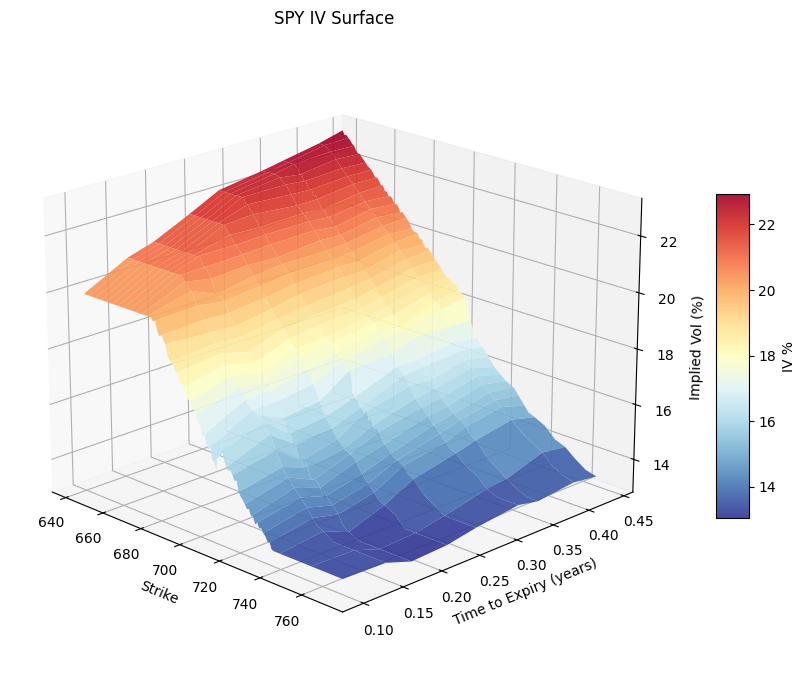

In [51]:
# SPY IV surface — monthly expiries
snap    = snapshots["SPY"]
monthly = [
    e for e in sorted(snap["options"]["expiry"].unique())
    if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
][:9]

options_monthly = snap["options"][snap["options"]["expiry"].isin(monthly)]
print(f"SPY surface — {len(monthly)} expiries, {len(options_monthly)} rows")
plot_surface(options_monthly, spot=snap["spot"], title="SPY IV Surface")

NVDA surface — 8 expiries, 1993 rows


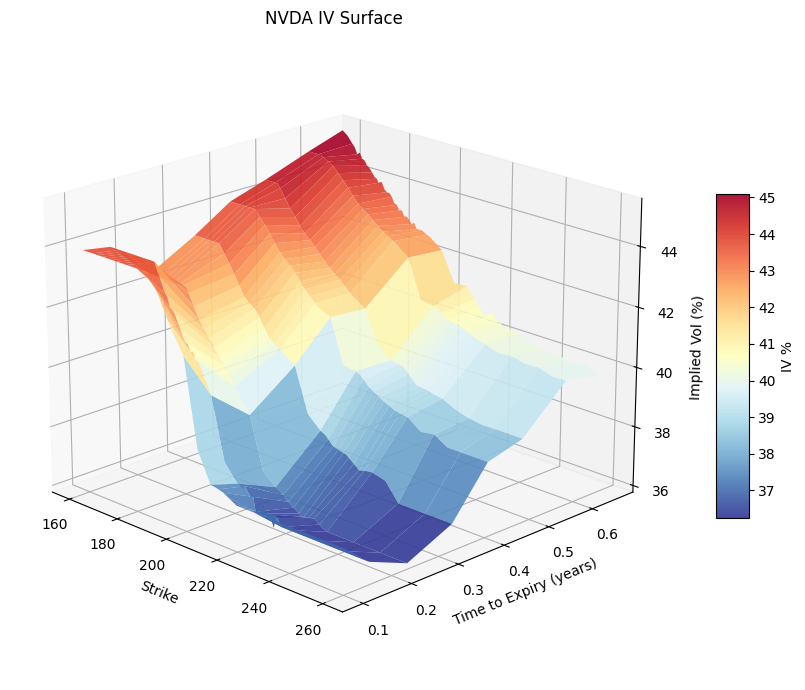

In [52]:
# NVDA IV surface — notice steeper skew and higher IV levels vs SPY
snap    = snapshots["NVDA"]
monthly = [
    e for e in sorted(snap["options"]["expiry"].unique())
    if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
][:9]

options_monthly = snap["options"][snap["options"]["expiry"].isin(monthly)]
print(f"NVDA surface — {len(monthly)} expiries, {len(options_monthly)} rows")
plot_surface(options_monthly, spot=snap["spot"], title="NVDA IV Surface")

TSLA surface — 8 expiries, 1643 rows


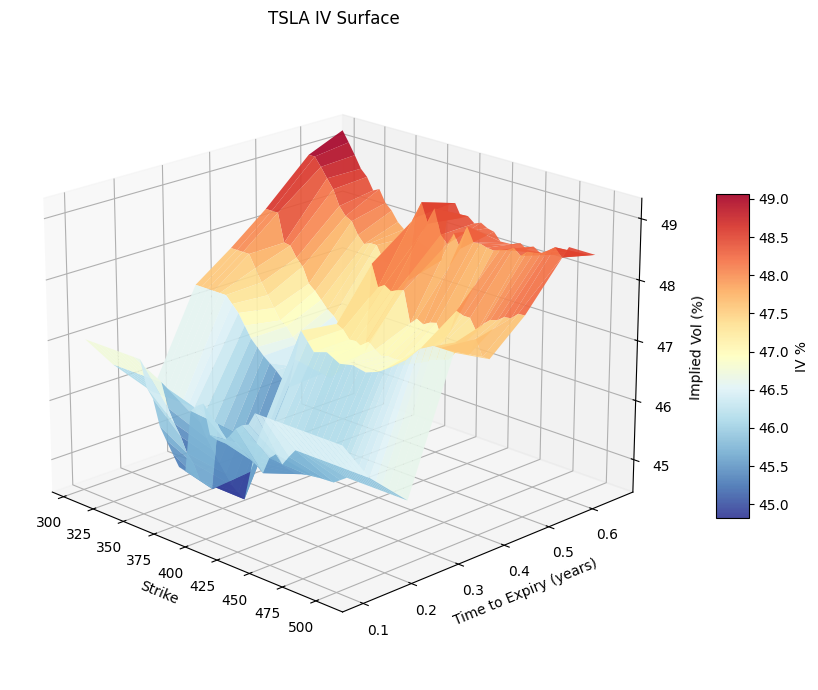

In [64]:
# TSLA IV surface — high single-stock vol, steep skew from earnings risk
snap    = snapshots["TSLA"]
monthly = [
    e for e in sorted(snap["options"]["expiry"].unique())
    if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
][:9]

options_monthly = snap["options"][snap["options"]["expiry"].isin(monthly)]
print(f"TSLA surface — {len(monthly)} expiries, {len(options_monthly)} rows")
plot_surface(options_monthly, spot=snap["spot"], title="TSLA IV Surface")

GOOG surface — 7 expiries, 767 rows


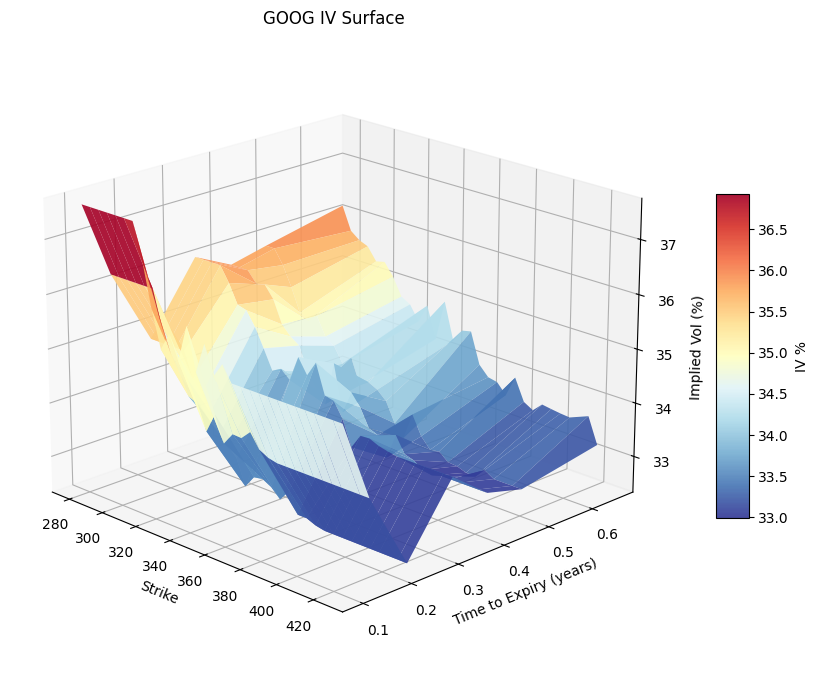

In [65]:
# GOOGL IV surface — mega-cap single stock, compare skew shape vs SPY
snap    = snapshots["GOOG"]
monthly = [
    e for e in sorted(snap["options"]["expiry"].unique())
    if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
][:9]

options_monthly = snap["options"][snap["options"]["expiry"].isin(monthly)]
print(f"GOOG surface — {len(monthly)} expiries, {len(options_monthly)} rows")
plot_surface(options_monthly, spot=snap["spot"], title="GOOG IV Surface")

In [ ]:
# cross-ticker ATM IV comparison
vix = yf.Ticker("^VIX").history(period="1d")["Close"].iloc[-1]

print(f"ATM Implied Volatility Comparison")
print(f"VIX today: {vix:.1f}%\n")
print(f"{'Ticker':<8} {'Spot':>8} {'ATM IV':>10} {'Basis vs VIX':>14} {'Expiry'}")

for ticker in ["SPY", "AAPL", "NVDA"]:
    snap = snapshots[ticker]
    s    = snap["spot"]
    opts = snap["options"]

    target = next(
        (e for e in sorted(opts["expiry"].unique())
         if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30),
        sorted(opts["expiry"].unique())[3]
    )

    iv    = atm_implied_vol(opts, s, expiry=target)
    basis = iv * 100 - vix
    print(f"{ticker:<8} ${s:>7.1f} {iv*100:>9.1f}% {basis:>+13.1f}% {target}")

print("\nSingle stocks always have higher IV than SPY — no diversification benefit")

ATM Implied Volatility Comparison
VIX today: 19.2%

Ticker       Spot     ATM IV   Basis vs VIX Expiry
SPY      $  709.6      16.2%          -3.0% 2026-05-29
AAPL     $  271.6      28.2%          +9.0% 2026-05-29
NVDA     $  201.2      40.3%         +21.1% 2026-05-29

Single stocks always have higher IV than SPY — no diversification benefit


---
## 4. vol_spread

The strategy module. Computes the **Variance Risk Premium** — the spread between implied and realized volatility.

VRP(t) = IV(t) - RV(t)

When VRP > 0, options are overpriced — the market pays more for protection than realized vol warrants. This is the systematic signal that vol sellers exploit.

### 4.1 Realized Volatility

In [54]:
# realized volatility across tickers — rolling 21-day window
print(f"{'Ticker':<8} {'Last RV (21d)':>14} {'Mean RV (1y)':>14} {'Min RV':>10} {'Max RV':>10}")

for ticker in ["SPY", "AAPL", "NVDA"]:
    ph = snapshots[ticker]["price_history"]
    rv = realized_vol(ph, window=21)
    print(f"{ticker:<8} {rv.iloc[-1]*100:>13.1f}% {rv.mean()*100:>13.1f}% "
          f"{rv.min()*100:>9.1f}% {rv.max()*100:>9.1f}%")

print("\nRV confirms the IV ranking — NVDA most volatile, SPY least")

Ticker    Last RV (21d)   Mean RV (1y)     Min RV     Max RV
SPY               17.8%          11.9%       5.7%      19.9%
AAPL              24.6%          22.1%       9.5%      33.8%
NVDA              32.4%          32.9%      22.0%      47.0%

RV confirms the IV ranking — NVDA most volatile, SPY least


In [56]:
# how does window size affect RV? shorter windows are noisier
ph = snapshots["SPY"]["price_history"]

print(f"SPY Realized Volatility — different window sizes")
print(f"{'Window':<10} {'Last RV':>10} {'Mean':>10} {'Std dev':>10}")
for window in [5, 10, 21, 42, 63]:
    rv = realized_vol(ph, window=window)
    print(f"{window:>4}d{'':<4} {rv.iloc[-1]*100:>9.1f}% {rv.mean()*100:>9.1f}% {rv.std()*100:>9.1f}%")
print("\n21 trading days (1 month) is the standard — matches VIX 30-day convention")

SPY Realized Volatility — different window sizes
Window        Last RV       Mean    Std dev
   5d          11.8%      11.4%       5.5%
  10d          10.0%      11.9%       4.2%
  21d          17.8%      11.9%       3.2%
  42d          16.4%      11.6%       2.1%
  63d          14.9%      11.5%       1.5%

21 trading days (1 month) is the standard — matches VIX 30-day convention


### 4.2 Vol Spread — Three Modes

**Why VIX as IV proxy?**

Yahoo Finance does not provide historical options chains — we cannot run the solver on past data. VIX is the CBOE's daily measure of 30-day implied vol, computed from real SPX option prices. It is the industry standard proxy for historical IV.

**Three modes:**

| Mode | IV series | When to use |
|------|-----------|-------------|
| vix_adjusted | VIX history + today's basis correction | Default — most consistent with the solver |
| vix_raw | Raw VIX history with no adjustment | Historical analysis where today's options aren't relevant |
| scalar | Single flat IV value | Quick sanity check or when you have an external IV estimate |

**Basis adjustment:** our solver differs slightly from VIX due to different underlying (SPY vs SPX) and strike selection. We correct this:

basis          = our_IV_today - VIX_today  

IV_adjusted(t) = VIX(t) + basis


  VIX today         : 19.5%
  Our ATM IV today  : 15.9%
  Basis             : -3.6%
------------------------------------------------------------
SPY Vol Spread Analysis
  Realized Vol (21d) : 17.8%
  Current Spread    : -1.9%
  Vol rich          : 78% of the time
  Regime            : NEUTRAL


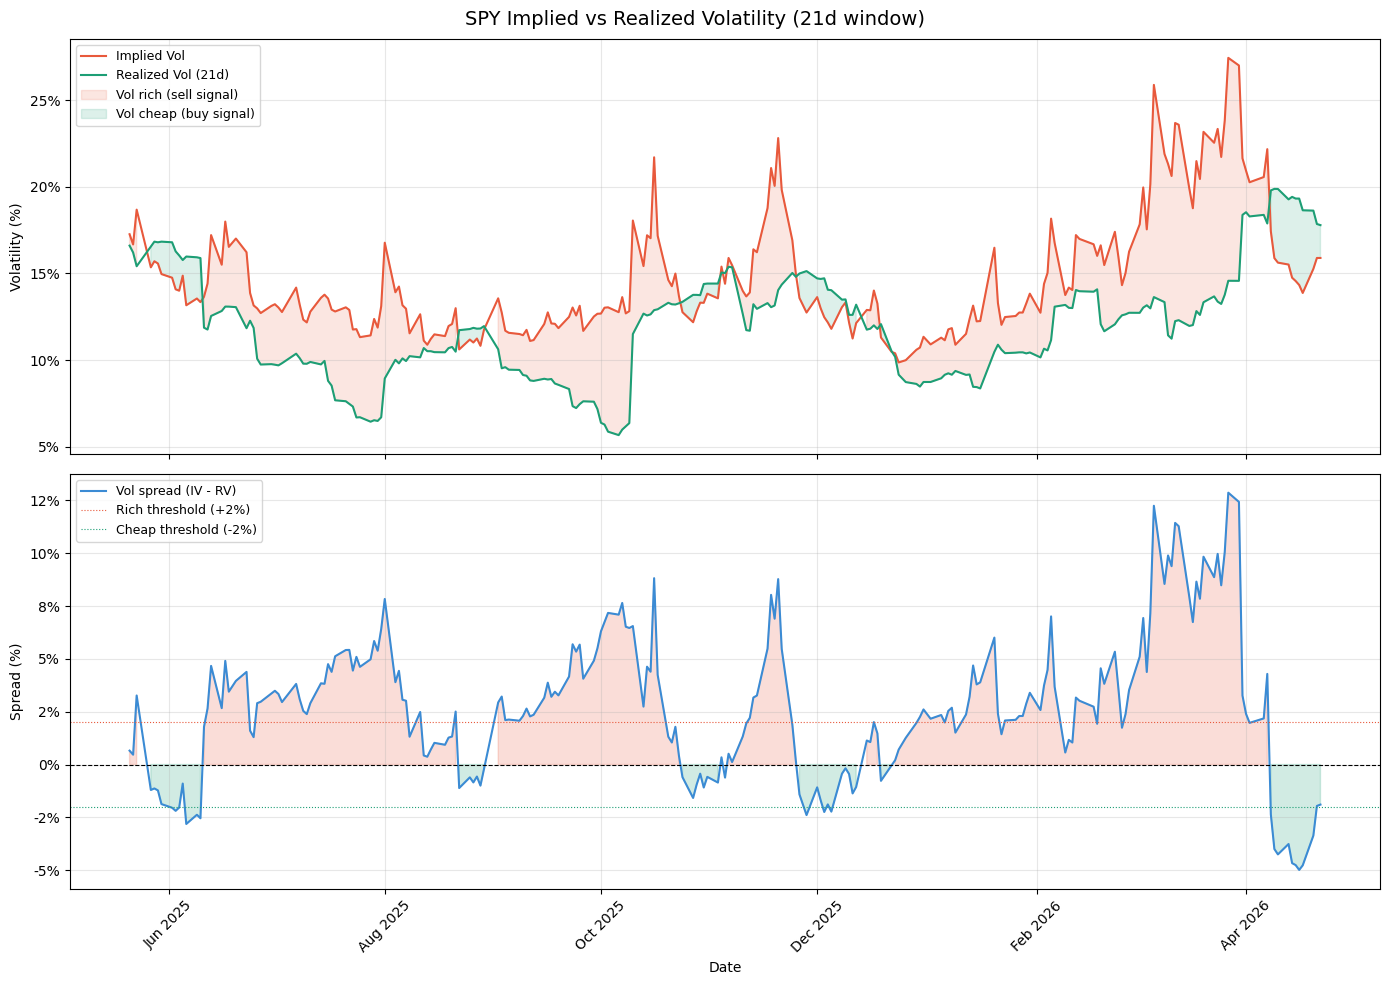

In [41]:
# SPY vol spread — vix_adjusted mode (recommended)
snap = snapshots["SPY"]

target = next(
    e for e in sorted(snap["options"]["expiry"].unique())
    if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
)

spread_spy = analyze_vol_spread(
    price_history=snap["price_history"],
    options=snap["options"],
    spot=snap["spot"],
    ticker="SPY",
    window=21,
    expiry=target,
    mode="vix_adjusted",
    rich_threshold=0.02,
)

  VIX today         : 19.5%
  Our ATM IV today  : 39.9%
  Basis             : +20.4%
------------------------------------------------------------
NVDA Vol Spread Analysis
  Realized Vol (21d) : 32.4%
  Current Spread    : +7.5%
  Vol rich          : 83% of the time
  Regime            : RICH — vol expensive, consider selling


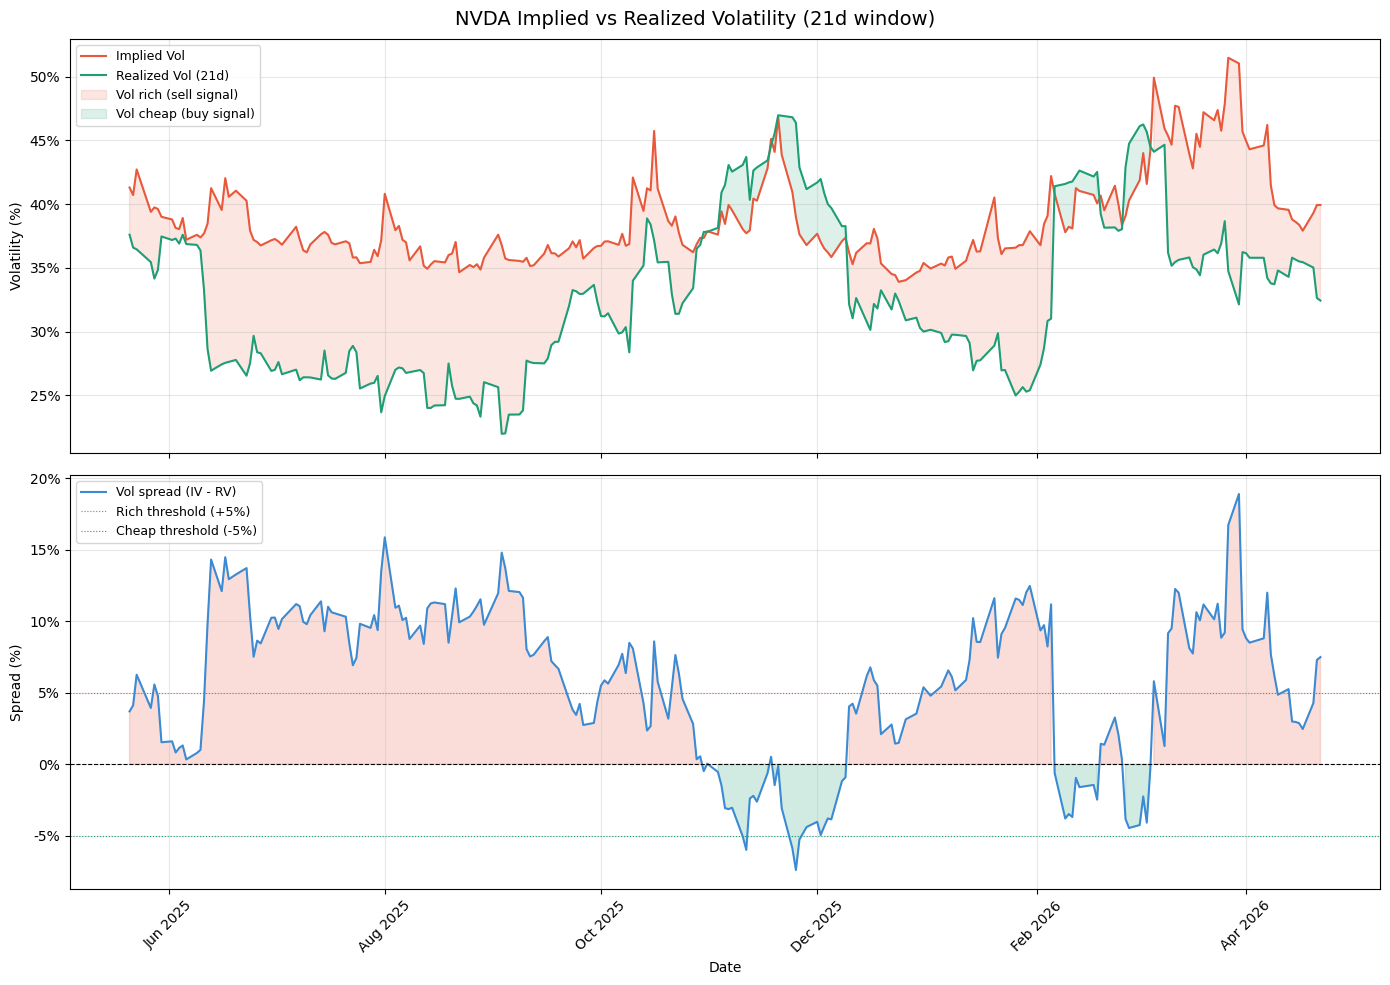

In [42]:
# NVDA vol spread — notice higher absolute spread levels
snap = snapshots["NVDA"]

target = next(
    e for e in sorted(snap["options"]["expiry"].unique())
    if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
)

spread_nvda = analyze_vol_spread(
    price_history=snap["price_history"],
    options=snap["options"],
    spot=snap["spot"],
    ticker="NVDA",
    window=21,
    expiry=target,
    mode="vix_adjusted",
    rich_threshold=0.05,   # higher threshold for single stocks — larger spreads are normal
)

### 4.3 Historical Analysis

Using vix_raw mode and custom date ranges, we can analyze VRP over any historical period. without needing today's options chain. This is the right mode for backtesting or studying specific market regimes.

------------------------------------------------------------
SPY 2024 Vol Spread Analysis
  Realized Vol (21d) : 14.4%
  Current Spread    : +3.0%
  Vol rich          : 90% of the time
  Regime            : RICH — vol expensive, consider selling


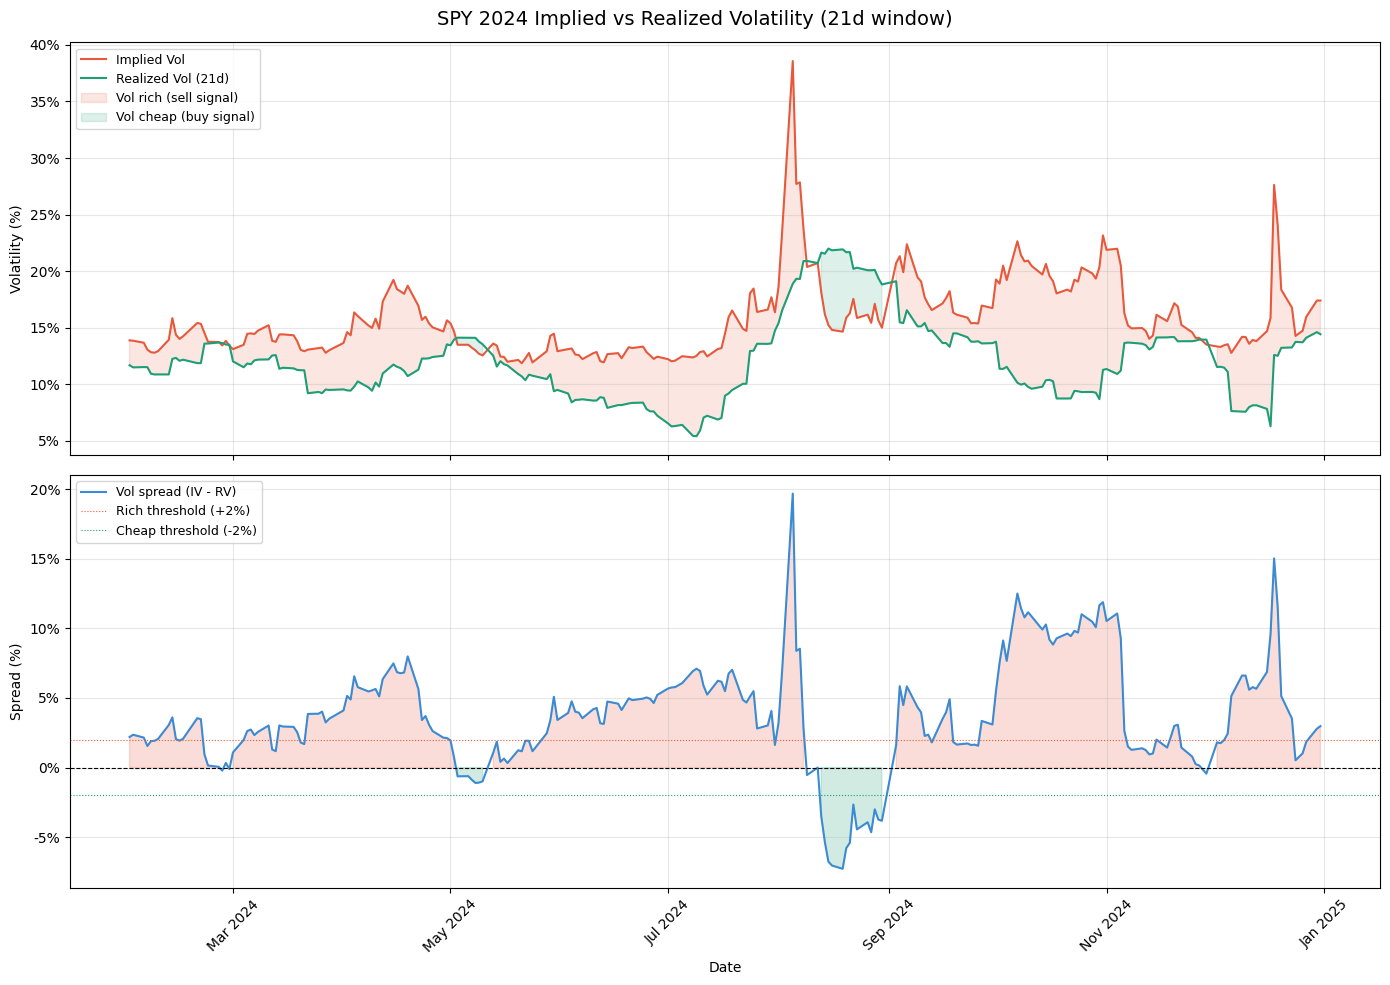

,close,realized_vol,implied_vol,spread
Date,,,,
2024-02-01,476.097961,0.116818,0.1388,0.021982
2024-02-02,481.109985,0.114894,0.1385,0.023606
2024-02-05,479.358246,0.115169,0.1367,0.021531
2024-02-06,480.749969,0.115100,0.1306,0.015500
2024-02-07,484.759644,0.109301,0.1283,0.018999
...,...,...,...,...
2024-12-24,592.702087,0.137460,0.1427,0.005240
2024-12-26,592.741516,0.137099,0.1473,0.010201
2024-12-27,586.502075,0.141067,0.1595,0.018433


In [58]:
# SPY vol spread during 2024 — a low-volatility bull market year
ph_2024 = market_data.get_price_history("SPY", start="2024-01-01", end="2025-01-01")

analyze_vol_spread(
    price_history=ph_2024,
    options=snapshots["SPY"]["options"],
    spot=snapshots["SPY"]["spot"],
    ticker="SPY 2024",
    window=21,
    mode="vix_raw",   # use raw VIX for historical periods — no basis adjustment
    rich_threshold=0.02,
)

In [57]:
# extract the spread DataFrame for custom analysis
ph_2y = market_data.get_price_history("SPY", period="2y")

spread_df = compute_vol_spread(
    price_history=ph_2y,
    options=snapshots["SPY"]["options"],
    spot=snapshots["SPY"]["spot"],
    window=21,
    mode="vix_raw",
)

# summary statistics
print("SPY Vol Spread — 2 Year Statistics")
print(f"  Mean spread   : {spread_df['spread'].mean()*100:+.1f}%")
print(f"  Median spread : {spread_df['spread'].median()*100:+.1f}%")
print(f"  % time RICH   : {(spread_df['spread'] > 0.02).mean()*100:.0f}%")
print(f"  % time CHEAP  : {(spread_df['spread'] < -0.02).mean()*100:.0f}%")
print(f"  Max spread    : {spread_df['spread'].max()*100:+.1f}%")
print(f"  Min spread    : {spread_df['spread'].min()*100:+.1f}%")
print("\nThe VRP is positive the vast majority of the time — options are systematically overpriced")

SPY Vol Spread — 2 Year Statistics
  Mean spread   : +3.9%
  Median spread : +4.9%
  % time RICH   : 74%
  % time CHEAP  : 9%
  Max spread    : +21.1%
  Min spread    : -29.5%

The VRP is positive the vast majority of the time — options are systematically overpriced


---
## Summary

volkit implements the full variance risk premium pipeline:

| Step | Module | Function | What it produces |
|------|--------|----------|------------------|
| 1 | `market_data` | `get_market_snapshot()` | Spot, price history, options chain |
| 2 | `black_scholes` | `bs_price()`, `greeks()` | Theoretical price and sensitivities |
| 3 | `iv_surface` | `build_iv_surface()` | IV for every strike and expiry |
| 4 | `iv_surface` | `plot_surface()` | 3D surface showing skew and term structure |
| 5 | `vol_spread` | `realized_vol()` | Rolling annualized RV from price history |
| 6 | `vol_spread` | `atm_implied_vol()` | ATM IV from options chain |
| 7 | `vol_spread` | `analyze_vol_spread()` | VRP signal — RICH / CHEAP / NEUTRAL |

**Key observations from this guide:**
- Single stocks (AAPL, NVDA) always carry higher IV than SPY — idiosyncratic risk is not diversified away
- Put skew is steeper on single stocks — the market prices more crash risk than for indices
- The VRP is positive the vast majority of the time — options are systematically overpriced relative to realized vol

**Known limitations:**
- Yahoo Finance does not provide liquid OTM puts far below spot — full put wing requires MarketData.app
- Yahoo Finance has no historical options chains — VIX is used as IV proxy for the vol spread
- MarketData.app free tier has daily credit limits — use `expiry_from` / `expiry_to` to limit fetches
- The IV surface requires at least 2 expiries with `T > 0`; options expiring today return `NaN`

**Natural extensions:** SVI/Heston surface model · intraday realized vol · backtest module

github.com/fedecarz/volkit